# Cross-Model Comparison

This notebook combines the results of all three model notebooks and compares them
side by side.

**Models**

| Model | Notebook | Results file |
|---|---|---|
| Llama 3.1 8B Instruct | `Notebooks/notebook_llama.ipynb` | `Results/results_llama.json` |
| Mistral 7B Instruct v0.3 | `Notebooks/notebook_mistral.ipynb` | `Results/results_mistral.json` |
| Gemma 4 E4B IT | `Notebooks/notebook_gemma.ipynb` | `Results/results_gemma.json` |

**Prompting techniques:** zero-shot, few-shot, few-shot CoT, zero-shot CoT.

**Metrics:** Exact Match, Contains Match, ROUGE-L, BERTScore F1, F1 token overlap,
plus agreement with the Llama-3.3-70B reference (ROUGE-L vs 70B, BERTScore vs 70B).

> `no_answer` questions (18) are excluded from metric scoring — there is no
> reference answer to score against. That leaves 82 scored questions × 4
> techniques = 328 scored rows per model.


## 1. Setup

In [1]:
print("Dependencies handled by the .venv")

Dependencies handled by the .venv


In [2]:
import os

os.environ.setdefault("HF_HOME", os.path.abspath(".hf_cache"))

import json
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from collections import Counter
from rouge_score import rouge_scorer
from bert_score import score as compute_bert_score

sns.set_theme(style="whitegrid", context="talk")
pd.set_option("display.float_format", lambda v: f"{v:.4f}")

d:\Projects\University\nlp_project\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 2. Configuration & data loading

In [3]:
PROJECT_PATH = "."

ANSWER_MARKER = "ANSWER:"

MODELS = [
    ("llama",   "Llama 3.1 8B"),
    ("mistral", "Mistral 7B v0.3"),
    ("gemma",   "Gemma 4 E4B"),
]
MODEL_ORDER  = [label for _, label in MODELS]

TECH_ORDER   = ["zero_shot", "few_shot", "few_shot_cot", "zero_shot_cot"]
TECH_LABELS  = {
    "zero_shot": "Zero-shot",
    "few_shot": "Few-shot",
    "few_shot_cot": "Few-shot CoT",
    "zero_shot_cot": "Zero-shot CoT",
}

METRICS = ["exact_match", "contains_match", "rouge_l", "bertscore_f1", "f1_token"]
METRICS_70B = ["rouge_l_vs_70b", "bertscore_vs_70b"]
METRIC_LABELS = {
    "exact_match": "Exact Match",
    "contains_match": "Contains Match",
    "rouge_l": "ROUGE-L",
    "bertscore_f1": "BERTScore F1",
    "f1_token": "F1 Token",
    "rouge_l_vs_70b": "ROUGE-L vs 70B",
    "bertscore_vs_70b": "BERTScore vs 70B",
}

In [4]:
frames = []
for stem, label in MODELS:
    with open(f"{PROJECT_PATH}/Results/results_{stem}.json", encoding="utf-8") as f:
        rows = json.load(f)
    frame = pd.DataFrame(rows)
    frame["model"] = label
    frames.append(frame)

df = pd.concat(frames, ignore_index=True)
df["model"] = pd.Categorical(df["model"], categories=MODEL_ORDER, ordered=True)
df["technique"] = pd.Categorical(df["technique"], categories=TECH_ORDER, ordered=True)

print(f"Loaded {len(df)} rows ({len(MODELS)} models x 100 questions x 4 techniques)")
print(df.groupby("model", observed=True)["technique"].value_counts().unstack())

Loaded 1200 rows (3 models x 100 questions x 4 techniques)
technique        zero_shot  few_shot  few_shot_cot  zero_shot_cot
model                                                            
Llama 3.1 8B           100       100           100            100
Mistral 7B v0.3        100       100           100            100
Gemma 4 E4B            100       100           100            100


In [5]:
with open(f"{PROJECT_PATH}/Data/sampled.jsonl", encoding="utf-8") as f:
    dataset = [json.loads(line) for line in f]

ref_70b = {}
for item in dataset:
    if item.get("responses"):
        ref_70b[item["sample_id"]] = item["responses"][0]["response"]

print(f"70B reference responses available for {len(ref_70b)} questions")
print("\nAnswer-type distribution (per model):")
print(df[df["model"] == MODEL_ORDER[0]]["answer_type"].value_counts())

70B reference responses available for 100 questions

Answer-type distribution (per model):
answer_type
short          148
long           140
no_answer       72
single_word     40
Name: count, dtype: int64


## 3. Evaluation functions

These are copied verbatim from the per-model notebooks so the recomputed scores
match exactly what each teammate reported.

In [6]:
def normalize_latex(text):
    text = re.sub(r'\\frac\{([^}]+)\}\{([^}]+)\}', r'\1/\2', text)
    text = re.sub(r'\\boxed\{([^}]+)\}', r'\1', text)
    text = re.sub(r'\$+', '', text)
    text = re.sub(r'\\(left|right|quad|qquad|text|mathrm|mathbf|displaystyle)\b', '', text)
    text = re.sub(r'\\{2,}', '', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def extract_answer(response):
    if ANSWER_MARKER in response:
        return response.split(ANSWER_MARKER)[-1].strip()

    boxed = re.findall(r'\\boxed\{([^}]+)\}', response)
    if boxed:
        return boxed[-1]

    patterns = [
        r'(?:the\s+)?(?:final\s+)?answer\s+is[:\s]+(.+?)(?:\.|$)',
        r'therefore[,:\s]+(.+?)(?:\.|$)',
    ]
    for pattern in patterns:
        match = re.search(pattern, response, re.IGNORECASE | re.DOTALL)
        if match:
            return match.group(1).strip()

    sentences = [s.strip() for s in response.rstrip('.').split('.') if s.strip()]
    return sentences[-1] if sentences else response

def normalize(text):
    text = normalize_latex(text)
    return text.lower().strip().rstrip('.')

In [7]:
rouge_l_scorer = rouge_scorer.RougeScorer(['rougeL'], use_stemmer=True)

def exact_match(prediction, reference):
    return normalize(extract_answer(prediction)) == normalize(reference)

def contains_match(prediction, reference):
    return normalize(reference) in normalize(prediction)

def compute_rouge_l(prediction, reference):
    return rouge_l_scorer.score(reference, prediction)['rougeL'].fmeasure

def compute_f1_token(prediction, reference):
    pred_tokens = normalize(extract_answer(prediction)).split()
    ref_tokens = normalize(reference).split()
    if not pred_tokens or not ref_tokens:
        return 0.0
    pred_counts, ref_counts = Counter(pred_tokens), Counter(ref_tokens)
    common = sum((pred_counts & ref_counts).values())
    if not common:
        return 0.0
    precision = common / len(pred_tokens)
    recall = common / len(ref_tokens)
    return 2 * precision * recall / (precision + recall)

## 4. Compute metrics

Drop `no_answer` rows (nothing to score against), then score every remaining row.
BERTScore is run once over all models together for speed.

In [8]:
scored = df[df["answer_type"] != "no_answer"].copy()

scored["extracted_answer"] = scored["response"].apply(extract_answer)
scored["exact_match"]    = scored.apply(lambda r: exact_match(r["response"], r["reference_answer"]), axis=1)
scored["contains_match"] = scored.apply(lambda r: contains_match(r["response"], r["reference_answer"]), axis=1)
scored["rouge_l"]        = scored.apply(lambda r: compute_rouge_l(r["response"], r["reference_answer"]), axis=1)
scored["f1_token"]       = scored.apply(lambda r: compute_f1_token(r["response"], r["reference_answer"]), axis=1)
scored["has_marker"]     = scored["response"].str.contains(ANSWER_MARKER, regex=False)
scored["ref_70b"]        = scored["sample_id"].map(ref_70b)

print(f"Scored rows: {len(scored)}  ({scored['model'].nunique()} models)")
print(f"70B reference matched for: {scored['ref_70b'].notna().sum()} / {len(scored)} rows")

Scored rows: 984  (3 models)
70B reference matched for: 984 / 984 rows


In [9]:
mask_70b = scored["ref_70b"].notna()

preds_ref = scored["response"].tolist()
refs_ref  = scored["reference_answer"].tolist()
preds_70b = scored.loc[mask_70b, "response"].tolist()
refs_70b  = scored.loc[mask_70b, "ref_70b"].tolist()

print(f"Computing BERTScore for {len(preds_ref) + len(preds_70b)} pairs...")
_, _, F1 = compute_bert_score(preds_ref + preds_70b, refs_ref + refs_70b,
                              lang="en", verbose=True)

n_ref = len(preds_ref)
scored["bertscore_f1"] = F1[:n_ref].numpy()
scored.loc[mask_70b, "bertscore_vs_70b"] = F1[n_ref:].numpy()
scored.loc[mask_70b, "rouge_l_vs_70b"] = scored.loc[mask_70b].apply(
    lambda r: compute_rouge_l(r["response"], r["ref_70b"]), axis=1)
print("Done.")

Computing BERTScore for 1968 pairs...


d:\Projects\University\nlp_project\.venv\Lib\site-packages\huggingface_hub\file_download.py:137: UserWarning: `huggingface_hub` cache-system uses symlinks by default to efficiently store duplicated files but your machine does not support them in D:\Projects\University\nlp_project\.hf_cache\hub\models--roberta-large. Caching files will still work but in a degraded version that might require more space on your disk. This warning can be disabled by setting the `HF_HUB_DISABLE_SYMLINKS_WARNING` environment variable. For more details, see https://huggingface.co/docs/huggingface_hub/how-to-cache#limitations.
To support symlinks on Windows, you either need to activate Developer Mode or to run Python as an administrator. In order to activate developer mode, see this article: https://docs.microsoft.com/en-us/windows/apps/get-started/enable-your-device-for-development
  warnings.warn(message)
Loading weights: 100%|██████████| 389/389 [00:00<00:00, 5326.93it/s]
[transformers] RobertaModel LOAD RE

calculating scores...
computing bert embedding.


100%|██████████| 18/18 [14:16<00:00, 47.58s/it]


computing greedy matching.


100%|██████████| 31/31 [00:04<00:00,  6.88it/s]


done in 860.99 seconds, 2.29 sentences/sec
Done.


## 5. Results — metric tables

In [10]:
ALL_METRICS = METRICS + METRICS_70B

overall = (scored.groupby("model", observed=True)[ALL_METRICS]
           .mean().reindex(MODEL_ORDER).round(4))
overall = overall.rename(columns=METRIC_LABELS)
print("Overall metric scores by model (mean over all techniques):")
overall

Overall metric scores by model (mean over all techniques):


,Exact Match,Contains Match,ROUGE-L,BERTScore F1,F1 Token,ROUGE-L vs 70B,BERTScore vs 70B
model,,,,,,,
Llama 3.1 8B,0.0091,0.0640,0.0682,0.8097,0.1721,0.2710,0.8590
Mistral 7B v0.3,0.0000,0.0579,0.0827,0.8175,0.1700,0.2540,0.8570
Gemma 4 E4B,0.0030,0.0823,0.0483,0.7989,0.1054,0.2517,0.8505


In [11]:
by_tech = (scored.groupby(["model", "technique"], observed=True)[ALL_METRICS]
           .mean().round(4).rename(columns=METRIC_LABELS))
print("Metric scores by model and technique:")
by_tech

Metric scores by model and technique:


Exact Match  Contains Match  ROUGE-L  \
model           technique                                             
Llama 3.1 8B    zero_shot           0.0244          0.0610   0.0593   
                few_shot            0.0000          0.0610   0.0782   
                few_shot_cot        0.0000          0.0610   0.0769   
                zero_shot_cot       0.0122          0.0732   0.0586   
Mistral 7B v0.3 zero_shot           0.0000          0.0610   0.0688   
                few_shot            0.0000          0.0488   0.1057   
                few_shot_cot        0.0000          0.0610   0.0906   
                zero_shot_cot       0.0000          0.0610   0.0655   
Gemma 4 E4B     zero_shot           0.0000          0.0732   0.0463   
                few_shot            0.0000          0.0854   0.0512   
                few_shot_cot        0.0000          0.0854   0.0488   
                zero_shot_cot       0.0122          0.0854   0.0469   

                               BERTScore F1  F1 Token  ROUGE-L vs 70B  \
model           technique                                               
Llama 3.1 8B    zero_shot            0.8112    0.1700          0.2861   
                few_shot             0.8125    0.1309          0.2646   
                few_shot_cot         0.8081    0.2005          0.2459   
                zero_shot_cot        0.8071    0.1871          0.2874   
Mistral 7B v0.3 zero_shot            0.8147    0.2092          0.2785   
                few_shot             0.8292    0.1083          0.2219   
                few_shot_cot         0.8163    0.2041          0.2491   
                zero_shot_cot        0.8097    0.1583          0.2664   
Gemma 4 E4B     zero_shot            0.7999    0.1023          0.2564   
                few_shot             0.7997    0.1019          0.2511   
                few_shot_cot         0.7988    0.0951          0.2545   
                zero_shot_cot        0.7973    0.1221          0.2446   

                               BERTScore vs 70B  
model           technique                        
Llama 3.1 8B    zero_shot                0.8657  
                few_shot                 0.8567  
                few_shot_cot             0.8476  
                zero_shot_cot            0.8661  
Mistral 7B v0.3 zero_shot                0.8635  
                few_shot                 0.8540  
                few_shot_cot             0.8525  
                zero_shot_cot            0.8579  
Gemma 4 E4B     zero_shot                0.8521  
                few_shot                 0.8488  
                few_shot_cot             0.8531  
                zero_shot_cot            0.8481

In [12]:
best = pd.DataFrame({
    "Best model": overall.idxmax(),
    "Score": overall.max().round(4),
})
print("Best model per metric:")
best

Best model per metric:


,Best model,Score
Exact Match,Llama 3.1 8B,0.0091
Contains Match,Gemma 4 E4B,0.0823
ROUGE-L,Mistral 7B v0.3,0.0827
BERTScore F1,Mistral 7B v0.3,0.8175
F1 Token,Llama 3.1 8B,0.1721
ROUGE-L vs 70B,Llama 3.1 8B,0.2710
BERTScore vs 70B,Llama 3.1 8B,0.8590


## 6. Graphs

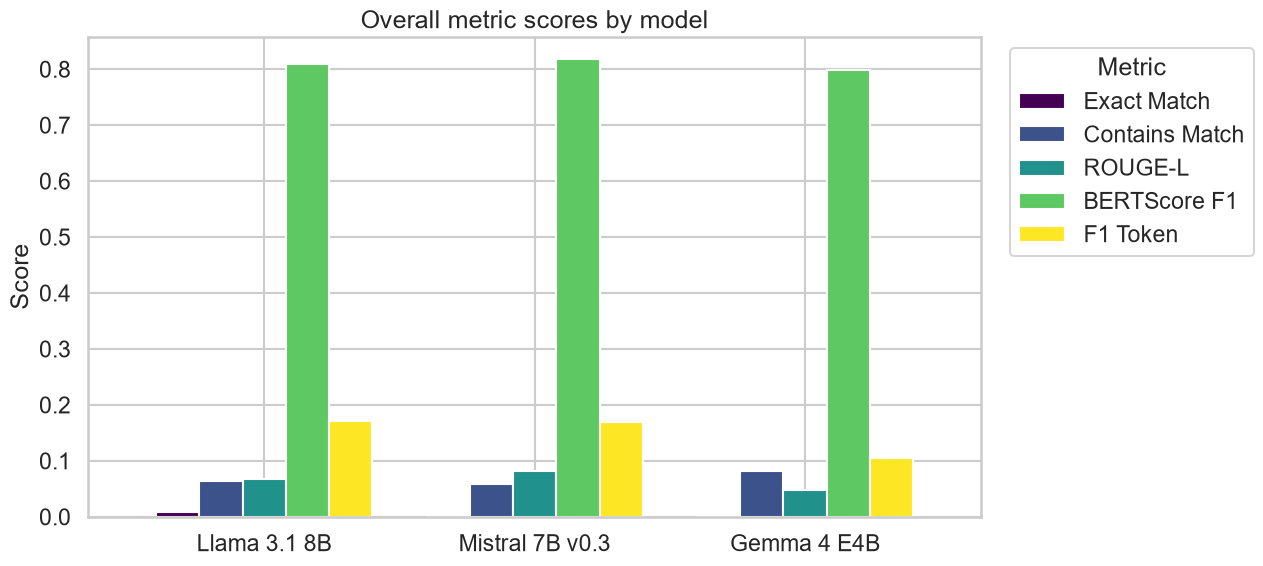

In [13]:
plot_df = overall[[METRIC_LABELS[m] for m in METRICS]].copy()
ax = plot_df.plot(kind="bar", figsize=(13, 6), width=0.8, colormap="viridis")
ax.set_title("Overall metric scores by model")
ax.set_xlabel("")
ax.set_ylabel("Score")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title="Metric", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

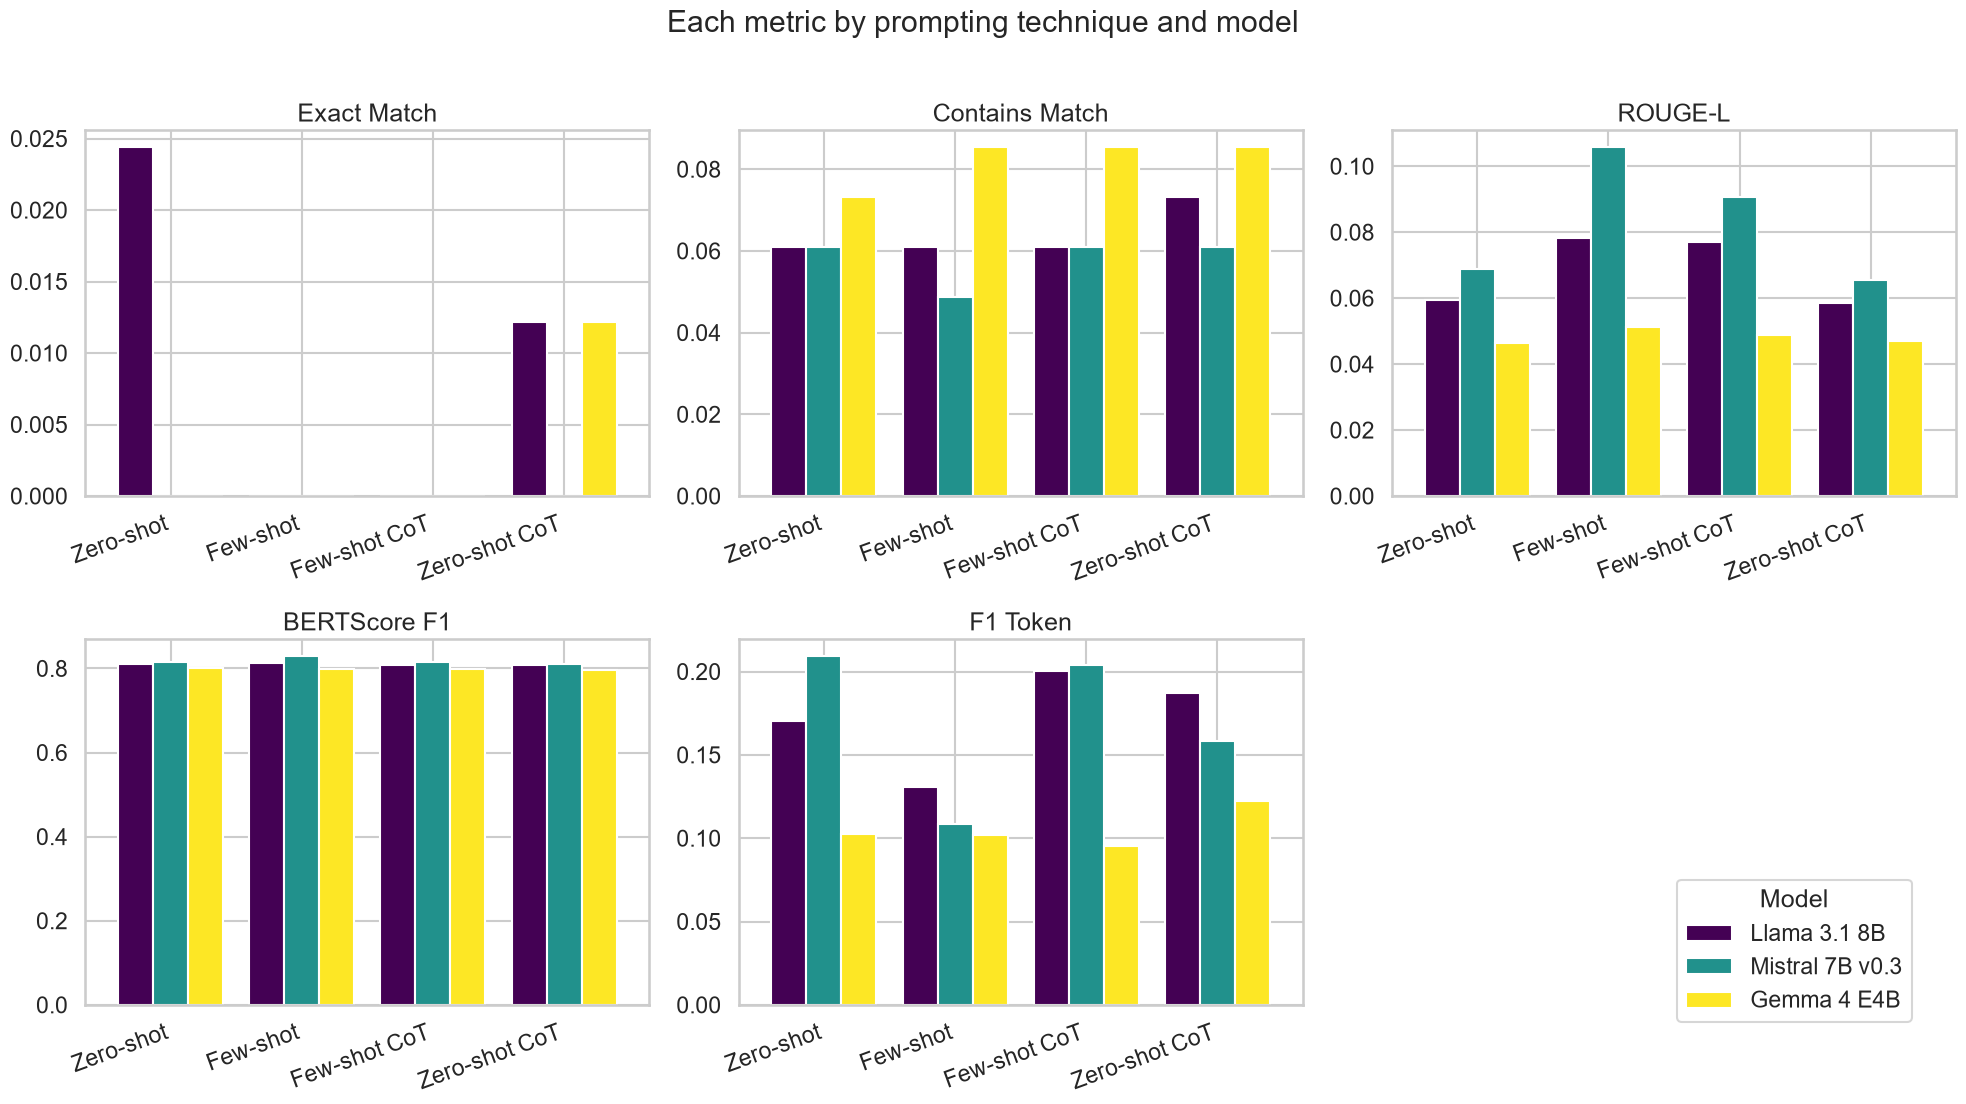

In [14]:
fig, axes = plt.subplots(2, 3, figsize=(20, 11))
for ax, metric in zip(axes.flat, METRICS):
    pivot = (scored.groupby(["technique", "model"], observed=True)[metric]
             .mean().unstack("model").reindex(TECH_ORDER)[MODEL_ORDER])
    pivot.index = [TECH_LABELS[t] for t in pivot.index]
    pivot.plot(kind="bar", ax=ax, width=0.8, colormap="viridis", legend=False)
    ax.set_title(METRIC_LABELS[metric])
    ax.set_xlabel("")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=20, ha="right")
axes.flat[-1].axis("off")
handles, labels = axes.flat[0].get_legend_handles_labels()
fig.legend(handles, labels, title="Model", loc="lower right", bbox_to_anchor=(0.97, 0.08))
fig.suptitle("Each metric by prompting technique and model", y=1.01)
plt.tight_layout()
plt.show()

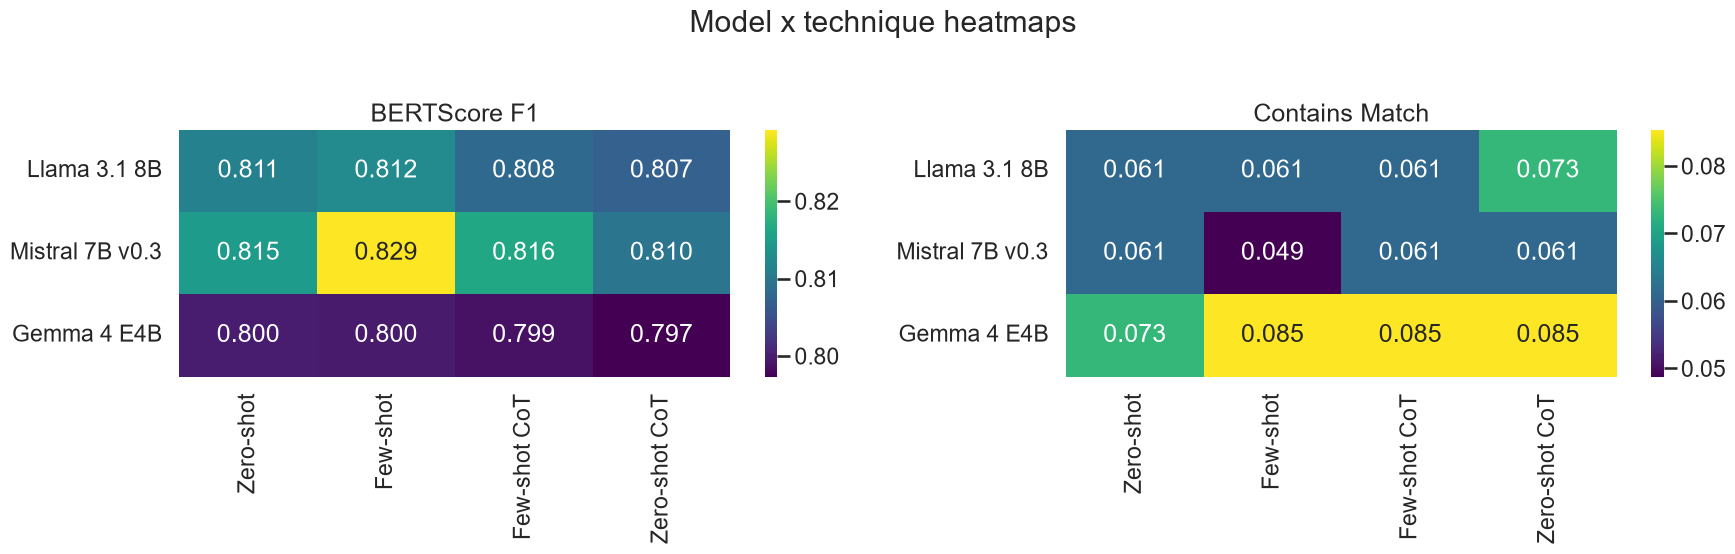

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(18, 5.5))
for ax, metric in zip(axes, ["bertscore_f1", "contains_match"]):
    pivot = (scored.groupby(["model", "technique"], observed=True)[metric]
             .mean().unstack("technique").reindex(MODEL_ORDER)[TECH_ORDER])
    pivot.columns = [TECH_LABELS[t] for t in pivot.columns]
    sns.heatmap(pivot, annot=True, fmt=".3f", cmap="viridis", ax=ax, cbar=True)
    ax.set_title(METRIC_LABELS[metric])
    ax.set_xlabel(""); ax.set_ylabel("")
fig.suptitle("Model x technique heatmaps", y=1.02)
plt.tight_layout()
plt.show()

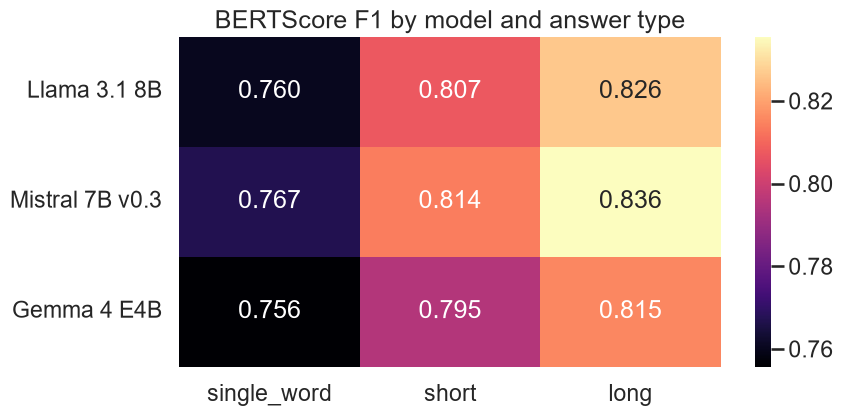

In [16]:
ANSWER_TYPE_ORDER = ["single_word", "short", "long"]
pivot = (scored.groupby(["model", "answer_type"], observed=True)["bertscore_f1"]
         .mean().unstack("answer_type").reindex(MODEL_ORDER)[ANSWER_TYPE_ORDER])
plt.figure(figsize=(9, 4.5))
sns.heatmap(pivot, annot=True, fmt=".3f", cmap="magma")
plt.title("BERTScore F1 by model and answer type")
plt.xlabel(""); plt.ylabel("")
plt.tight_layout()
plt.show()

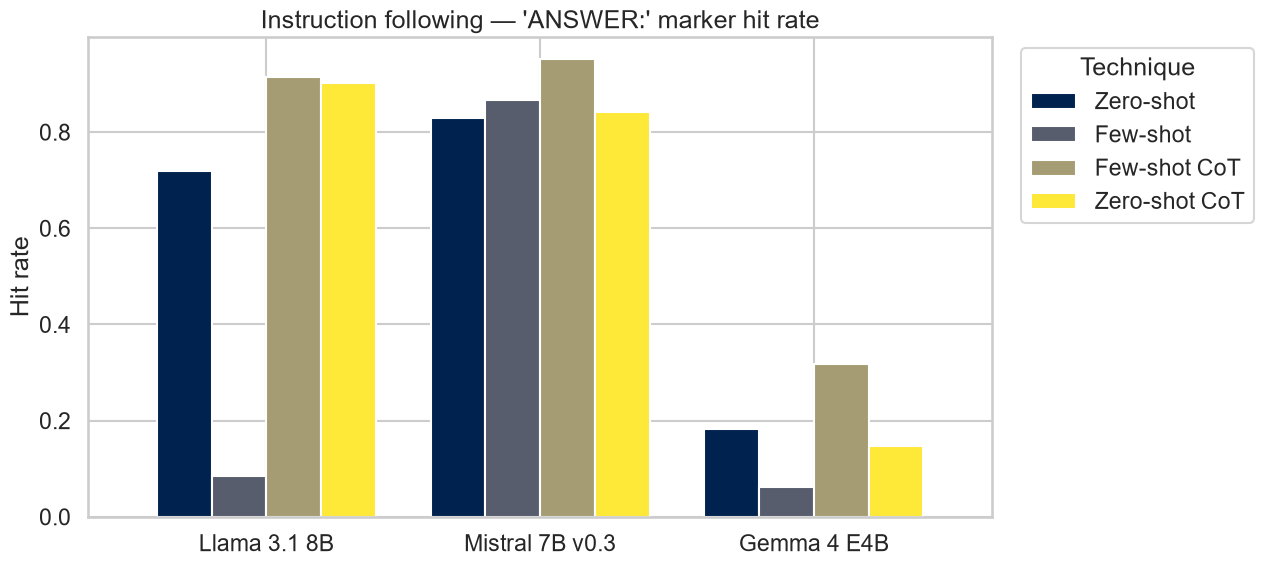

In [17]:
pivot = (scored.groupby(["model", "technique"], observed=True)["has_marker"]
         .mean().unstack("technique").reindex(MODEL_ORDER)[TECH_ORDER])
pivot.columns = [TECH_LABELS[t] for t in pivot.columns]
ax = pivot.plot(kind="bar", figsize=(13, 6), width=0.8, colormap="cividis")
ax.set_title("Instruction following — 'ANSWER:' marker hit rate")
ax.set_xlabel(""); ax.set_ylabel("Hit rate")
ax.set_xticklabels(ax.get_xticklabels(), rotation=0)
ax.legend(title="Technique", bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

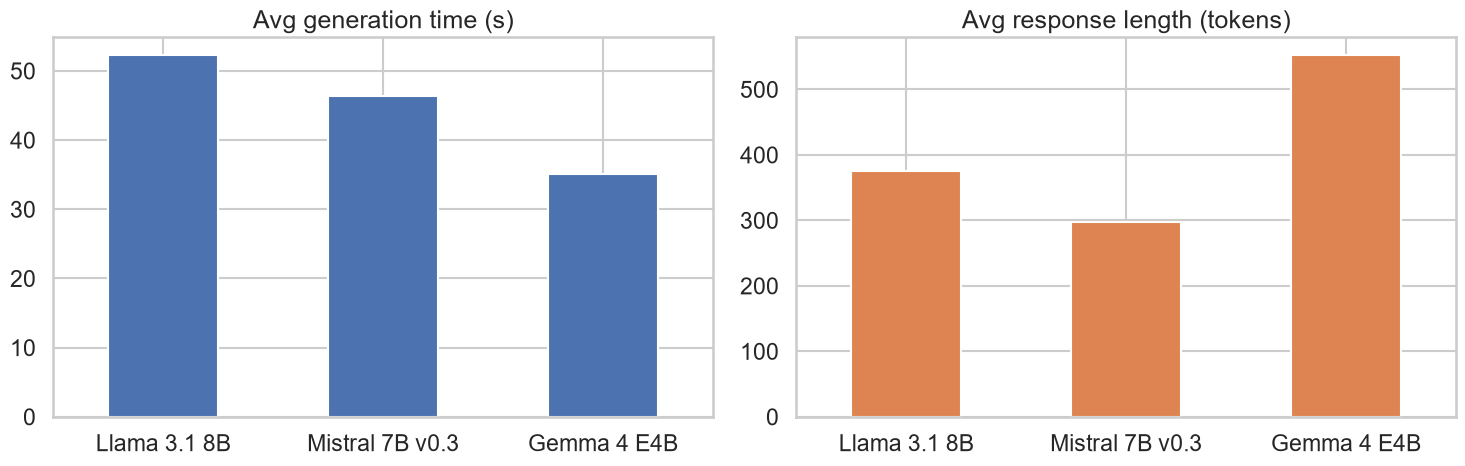

In [18]:
agg = (df.groupby("model", observed=True)
       .agg(avg_gen_time=("generation_time", "mean"),
            avg_resp_len=("response_length", "mean"))
       .reindex(MODEL_ORDER))
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
agg["avg_gen_time"].plot(kind="bar", ax=axes[0], color="#4C72B0")
axes[0].set_title("Avg generation time (s)"); axes[0].set_xlabel("")
axes[0].set_xticklabels(axes[0].get_xticklabels(), rotation=0)
agg["avg_resp_len"].plot(kind="bar", ax=axes[1], color="#DD8452")
axes[1].set_title("Avg response length (tokens)"); axes[1].set_xlabel("")
axes[1].set_xticklabels(axes[1].get_xticklabels(), rotation=0)
plt.tight_layout()
plt.show()

## 7. Qualitative comparison

In [19]:
def show_comparison(sample_id, technique="zero_shot", max_chars=600):
    rows = scored[(scored["sample_id"] == sample_id) & (scored["technique"] == technique)]
    if rows.empty:
        print(f"No scored rows for sample_id={sample_id}, technique={technique}")
        return
    first = rows.iloc[0]
    print(f"QUESTION (sample_id={sample_id}, {technique}):\n{first['question']}\n")
    print(f"GOLD REFERENCE:\n{first['reference_answer']}\n")
    print("=" * 90)
    for label in MODEL_ORDER:
        r = rows[rows["model"] == label]
        if r.empty:
            continue
        r = r.iloc[0]
        resp = r["response"][:max_chars] + ("..." if len(r["response"]) > max_chars else "")
        print(f"\n[{label}]  contains={r['contains_match']}  bertscore_f1={r['bertscore_f1']:.3f}")
        print(resp)
        print("-" * 90)

example_id = scored[scored["answer_type"] == "short"]["sample_id"].iloc[0]
show_comparison(example_id, technique="zero_shot")

QUESTION (sample_id=42, zero_shot):
Find all positive integer solutions to the equation $x^3=y^5+100$.

GOLD REFERENCE:
(7, 3)


[Llama 3.1 8B]  contains=False  bertscore_f1=0.773
To find the positive integer solutions to the equation $x^3 = y^5 + 100$, we can start by noticing that $y$ must be at least 1 since any smaller value of $y$ would result in a negative or zero value for $y^5 + 100$. 

We also know that $x^3 > y^5 + 100 \geq 101$. Since $2^3=8<101$, it follows that $x>2$. We will now check possible values of $x$ and see if they satisfy the given equation.

For x = 3:
\begin{align*}
    3^3 &= 27 \\
    y^5 + 100 &\neq 27.
\end{align*}

For x = 4:
\begin{align*}
    4^3 &= 64 \\
    y^5 + 100 &\neq 64.
\end{align*}

For x = 5:
\begin{align*}
    5^3 &= 125 \\
  ...
------------------------------------------------------------------------------------------

[Mistral 7B v0.3]  contains=False  bertscore_f1=0.779
To find the positive integer solutions for the given equation $x^3 = y